In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from pandas import read_sql
from sqlite3 import connect
import seaborn as sns
from datetime import datetime

In [2]:
# Create a static dashboard in a notebook using widgets to switch views, filters, or scenarios.
# • Include multiple visuals that highlight your key findings and support a narrative.
# • Include a short written summary in the dashboard that explains what the viewer should learn.

In [3]:
topic_list = ["code, software, development", "models, model, google", "just, like, work", "learning, machine, artificial", "enterprise, 2025, artificial"]

### Sentiment Distribution per Length

In [4]:
# Bar chart showing distribution of article length by sentiment
def chart_sentiment_dist_over_length(table_name, column, date_column, sentiment_threshold=0, length_threshold=500000):
    query = f"""SELECT {column}, IF(roberta_pos_score - roberta_neg_score > {sentiment_threshold}, 'positive', 'negative') sentiment, strftime('%Y-%m', {date_column}) month_released
                FROM {table_name}
                WHERE month_released BETWEEN "2021-01" AND "2025-12"
                ORDER BY month_released, strftime('%m', {date_column});"""
    conn = connect("db.sqlite")

    df = read_sql(query, conn)
    df["length"] = df[column].apply(len)
    df = df[df["length"] < length_threshold]
    return df

In [5]:
@widgets.interact(sentiment_threshold=(-1, 1, 0.1), news_length_threshold=(10000, 100000, 5000), devposts_length_threshold=(10000, 100000, 5000))
def display_sen_by_len(sentiment_threshold, news_length_threshold, devposts_length_threshold):
    articles_df = chart_sentiment_dist_over_length("modified_articles", "text", date_column="date", sentiment_threshold=sentiment_threshold, length_threshold=news_length_threshold)
    dp_df = chart_sentiment_dist_over_length("DevPosts", "body_text", date_column="published_at", sentiment_threshold=sentiment_threshold, length_threshold=devposts_length_threshold)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(x="sentiment", y='length', data=articles_df, ax=axes[0])

    sns.boxplot(x="sentiment", y='length', data=dp_df, ax=axes[1])
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
    axes[0].set_title("News Articles Sentiment Distribution by Length")
    axes[1].set_title("DevPosts Sentiment Distribution by Length")
    fig.supylabel("Length (chars)")
    fig.supxlabel("Sentiment")

interactive(children=(FloatSlider(value=0.0, description='sentiment_threshold', max=1.0, min=-1.0), IntSlider(…

### Sentiment Distribution per Topic

In [21]:
# Interactive pie chart to show % of articles/posts that are positive or negative with tabs to switch between different topics
def chart_sent_by_topic(topic_choice):
    query = f"""SELECT SUM(IF(roberta_pos_score - roberta_neg_score >= 0, 1, 0)) * 100 / count(*) positive,
            SUM(IF(roberta_pos_score - roberta_neg_score <= 0, 1, 0)) * 100 / count(*) negative
                    FROM DevPosts
                    WHERE dominant_topic = {topic_choice}
                    GROUP BY dominant_topic;"""
    conn = connect("db.sqlite")

    df = read_sql(query, conn).transpose()
    conn.close()
    return df

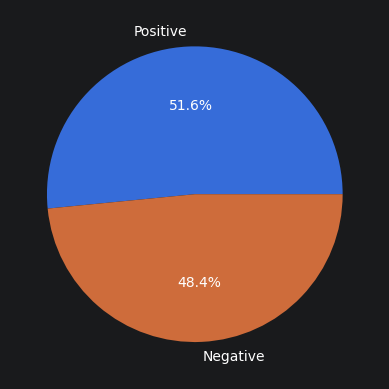

interactive(children=(Dropdown(description='topic_choice', options=(0, 1, 2, 3, 4), value=0), Output()), _dom_…

In [23]:
@widgets.interact(topic_choice=[0, 1, 2, 3, 4])
def display_sen_by_len(topic_choice):
    df = chart_sent_by_topic(topic_choice)
    plt.pie(df[0], labels=["Positive", "Negative"], autopct="%1.1f%%")
    plt.title("Developer Posts Sentiment Analysis Percentage by Topic")
    plt.figtext(0.33, 0.05, f"Topic: {topic_list[topic_choice]}")
    plt.show()

### Topic discussion over time

In [8]:
# Line chart with n lines per n topics popularity over time. Maybe have tabs per topic instead of lines on the same plot
def chart_topic_disc_over_time(post_per_month_threshold):
    query = f"""SELECT strftime('%Y-%m', published_at) month_released,
    SUM(IF(dominant_topic = 0, 1, 0)) topic_0,
    SUM(IF(dominant_topic = 1, 1, 0)) topic_1,
    SUM(IF(dominant_topic = 2, 1, 0)) topic_2,
    SUM(IF(dominant_topic = 3, 1, 0)) topic_3,
    SUM(IF(dominant_topic = 4, 1, 0)) topic_4
                    FROM DevPosts
                    where published_at < "2026-03-01"
                    GROUP BY month_released
                    HAVING COUNT(*) > {post_per_month_threshold}
                    ORDER BY month_released;"""

    conn = connect("db.sqlite")

    df = read_sql(query, conn)
    conn.close()
    df["month_released"] = df["month_released"].apply(lambda x: datetime.strptime(x, "%Y-%m"))
    plt.plot(df["month_released"], df["topic_0"], label=f"Topic 0: {topic_list[0]} ")
    plt.plot(df["month_released"], df["topic_1"], label=f"Topic 1: {topic_list[1]} ")
    plt.plot(df["month_released"], df["topic_2"], label=f"Topic 2: {topic_list[2]} ")
    plt.plot(df["month_released"], df["topic_3"], label=f"Topic 3: {topic_list[3]} ")
    plt.plot(df["month_released"], df["topic_4"], label=f"Topic 4: {topic_list[4]} ")


In [9]:
@widgets.interact(post_per_month_threshold=widgets.IntSlider(min=0, max=100, step=5, value=5))
def display_topic_disc_over_time(post_per_month_threshold):
    chart_topic_disc_over_time(post_per_month_threshold)
    plt.xlabel("Month")
    plt.ylabel("Topic")
    plt.title("Topic Change over Months")
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()


interactive(children=(IntSlider(value=5, description='post_per_month_threshold', step=5), Output()), _dom_clas…

### Sentiment changes over time

In [10]:
# Line chart with 2 lines, positive and negative sentiment over time
def chart_sentiment_change_over_months(table_name, column, threshold=0, post_per_month_threshold=5):
    query = f"""SELECT strftime('%Y-%m', {column}) month_released,
    SUM(IF(roberta_pos_score - roberta_neg_score >= {threshold}, 1, 0)) * 100 / count(*) positive,
    SUM(IF(roberta_pos_score - roberta_neg_score <= -{threshold}, 1, 0)) * 100 / count(*) negative
                FROM {table_name}
                WHERE month_released BETWEEN "2021-01" AND "2025-12"
                GROUP BY month_released
                HAVING COUNT(*) > {post_per_month_threshold}
                ORDER BY month_released;"""
    conn = connect("db.sqlite")

    df = read_sql(query, conn)
    df["month_released"] = df["month_released"].apply(lambda x: datetime.strptime(x, "%Y-%m"))
    return df

In [11]:
@widgets.interact(sentiment_threshold=(-1, 1, 0.1), post_per_month_threshold=widgets.IntSlider(min=0, max=100, step=5, value=5))
def display_sent_change_over_time(sentiment_threshold, post_per_month_threshold):
    articles_df = chart_sentiment_change_over_months("modified_articles", "date", threshold=sentiment_threshold, post_per_month_threshold=post_per_month_threshold)
    dp_df = chart_sentiment_change_over_months("DevPosts", "published_at", threshold=sentiment_threshold, post_per_month_threshold=post_per_month_threshold)

    plt.plot(articles_df["month_released"], articles_df["negative"], label="Negative News Articles")
    plt.plot(articles_df["month_released"], articles_df["positive"], label="Positive News Articles")

    plt.plot(dp_df["month_released"], dp_df["negative"], label="Negative DevPosts")
    plt.plot(dp_df["month_released"], dp_df["positive"], label="Positive DevPosts")
    plt.xlabel("Year")
    plt.ylabel("Sentiment %")
    plt.title("Sentiment Change over Year")
    plt.legend()
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='sentiment_threshold', max=1.0, min=-1.0), IntSlider(…